# **Model Training and Validation**
This section describes the development, training, and evaluation of machine learning models (**XGBoost, Random Forest, SVM, Logistic Regression, MLP**) for QSAR classification. The goal is to identify the best-performing model and descriptor subset combination using rigorous cross-validation and external test set validation.

## **Step1: Data Preparation** 
To construct a balanced training dataset, 508 positive compounds and an equal number of negative compounds were selected:
1. The positive set (n = 508) was predefined.
2. The negative set (n = 508) was randomly sampled from a larger pool (n = 6,458) using a fixed seed (random_state = 4916) to ensure reproducibility.
3. The test set (n = 438) was prepared separately.
These two subsets were concatenated to form a balanced training set (train_cls_1016.csv). 

### **Input and Output files:**
* Input files:
    * `Data/03_Model_training/01_Data_load/train_pos_508.csv`: Positive training samples
    * `Data/03_Model_training/01_Data_load/train_total_neg_6458.csv`: Full pool of negative samples
    * `Data/03_Model_training/01_Data_load/test_set_438.csv`
* Output files:
    * `Data/03_Model_training/01_Data_load/train_new_neg_508.csv`: Randomly selected negative samples
    * `Data/03_Model_training/01_Data_load/train_cls_1016.csv`: Final balanced training dataset

In [ ]:
import os

# Create all required output directories
os.makedirs("../Data/02_Preprocessed/01_Remove_duplication_NaN", exist_ok=True)
os.makedirs("../Data/02_Preprocessed/02_Filtered_metal_ions", exist_ok=True)
os.makedirs("../Data/03_Model_training/01_Data_load", exist_ok=True)
os.makedirs("../Data/03_Model_training/02_Output", exist_ok=True)
os.makedirs("../Model", exist_ok=True)

print("✅ All directories ready.")

In [1]:
import pandas as pd
import numpy as np
# Load positive samples
pos_sig = pd.read_csv("../Data/03_Model_training/01_Data_load/train_pos_508.csv", index_col='Name')

# Load total negative pool and randomly sample 508 negatives
total_neg_sig = pd.read_csv('../Data/03_Model_training/01_Data_load/train_total_neg_6458.csv', index_col='Name')
neg_sig = total_neg_sig.sample(n=508, random_state=4916)  # Ensures reproducibility

# Save sampled negatives
neg_sig.to_csv('../Data/03_Model_training/01_Data_load/train_new_neg_508.csv')

# Merge positives and negatives to form the final training set
train_cls = pd.concat([pos_sig, neg_sig])
train_cls.to_csv('../Data/03_Model_training/01_Data_load/train_cls_1016.csv')

# Load the external independent test set
test_cls = pd.read_csv("../Data/03_Model_training/01_Data_load/test_set_438.csv", index_col='Name')

## **Step2: Descriptor Clustering - UMAP Analysis**
We apply **UMAP** (Uniform Manifold Approximation and Projection) to visualize the separability of **antioxidant** and **non-antioxidant** compounds in 2D space.

**Descriptor sets:**
* Top 51 descriptors (first elbow point)
* Top 79 descriptors (including second elbow region)
* All 893 descriptors

**Analysis:**
- Apply UMAP to Top51, Top79, and All 893 descriptor sets
- Visualize class separation in reduced-dimensional space


**Figure 2B** UMAP of 1,016 compounds using the top 51 descriptors.
**Figure 2C** UMAP of 1,016 compounds using the top 79 descriptors.
**Figure 2D** UMAP of 1,016 compounds using all 893 descriptors.


### **Input and Output files:**
* Input file: `Data/02_Preprocessed/03_Feature_selection/Feature_Importances_300dataset.csv`
* Output files:
    * `Data/03_Model_training/02_Output/UMAP_top51.jpg`
    * `Data/03_Model_training/02_Output/UMAP_top79.jpg`
    * `Data/03_Model_training/02_Output/UMAP_893.jpg`

In [5]:
### Standardize the full descriptor matrix ###
from sklearn.preprocessing import StandardScaler
import fastcluster
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib import colors
import seaborn as sns
import os

# Data Load
importances_df = pd.read_csv("../Data/02_Preprocessed/03_Feature_selection/Feature_Importances_300dataset.csv", index_col=0)

median_importances = importances_df.median(axis=0)

median_importances_sorted = median_importances.sort_values(ascending=False)

# Prepare training data
X_cluster = train_cls.copy()
y_labels = X_cluster["y_true"]  # Binary class labels: 0 (Negative), 1 (Positive)

# Use only descriptor columns used in feature importance
X_cluster_com = X_cluster[importances_df.columns]

# Standardize descriptor values (mean=0, std=1)
scaler = StandardScaler()
scaled_x = scaler.fit_transform(X_cluster_com)
df_scaled_x = pd.DataFrame(scaled_x, columns=X_cluster_com.columns, index=X_cluster_com.index)

### Select Descriptor Subsets (Top51, Top79) ###
# Select top 51 and top 79 features based on elbow point analysis
top_51_features = median_importances_sorted.index[:51]
top_79_features = median_importances_sorted.index[:79]

# Extract feature subsets from training data
X_top_51 = train_cls[top_51_features]
X_top_79 = train_cls[top_79_features]

# Extract corresponding standardized data
elbow_1_51 = df_scaled_x[X_top_51.columns]
elbow_2_79 = df_scaled_x[X_top_79.columns]

# Define RGB values for class label coloring
light_red = (146/255, 0/255, 0/255)       # Light red for Negative
light_blue = (0/255, 32/255, 96/255)      # Light blue for Positive

# Convert RGB to HEX
light_red_hex = colors.to_hex(light_red)
light_blue_hex = colors.to_hex(light_blue)

# Map binary labels to string labels
y_str = y_labels.map({0: "Negative", 1: "Positive"})

# Assign colors based on class label
row_colors = y_str.rename(None).map({"Negative": light_red_hex, "Positive": light_blue_hex})
col_colors = y_str.rename(None).map({"Negative": light_red_hex, "Positive": light_blue_hex})

### **UMAP**

In [88]:
### UMAP Analysis ###
import umap

# UMAP parameters
umap_params = {
    'n_neighbors': 15,
    'min_dist': 0.01,
    'metric': 'euclidean',
    'random_state': 1004,
    'n_components': 2
}

# Apply UMAP to Top51 descriptors
umap_reducer_51 = umap.UMAP(**umap_params)
umap_embedding_51 = umap_reducer_51.fit_transform(elbow_1_51)
print("   ✓ UMAP completed for Top51 descriptors")

# Apply UMAP to Top79 descriptors
umap_reducer_79 = umap.UMAP(**umap_params)
umap_embedding_79 = umap_reducer_79.fit_transform(elbow_2_79)
print("   ✓ UMAP completed for Top79 descriptors")

# Apply UMAP to All 893 descriptors
umap_reducer_893 = umap.UMAP(**umap_params)
umap_embedding_893 = umap_reducer_893.fit_transform(df_scaled_x)
print("   ✓ UMAP completed for All 893 descriptors")

print("\n✅ UMAP analysis completed for all descriptor sets")

/home/zoo/miniforge3/envs/jupyter/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zoo/miniforge3/envs/jupyter/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   ✓ UMAP completed for Top51 descriptors


/home/zoo/miniforge3/envs/jupyter/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zoo/miniforge3/envs/jupyter/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   ✓ UMAP completed for Top79 descriptors


/home/zoo/miniforge3/envs/jupyter/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zoo/miniforge3/envs/jupyter/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   ✓ UMAP completed for All 893 descriptors

✅ UMAP analysis completed for all descriptor sets


In [90]:
### Visualization Function ###
def plot_dimreduction(embedding, title, filename, colors_array, y_labels, output_dir='../Data/03_Model_training/02_Output'):
    """
    Plot dimensionality reduction results (UMAP)
    
    Parameters:
    - embedding: 2D array of reduced dimensions
    - title: Plot title
    - filename: Output filename
    - colors_array: List of colors for each point
    - y_labels: Binary class labels
    - output_dir: Directory to save the figure
    """
    plt.figure(figsize=(10, 8))
    
    # Scatter plot with class-based coloring
    plt.scatter(
        embedding[:, 0], 
        embedding[:, 1],
        c=colors_array,
        s=30,
        alpha=0.7,
        edgecolors='none'
    )
    
    plt.xlabel('Component 1', fontsize=16, fontweight='bold')
    plt.ylabel('Component 2', fontsize=16, fontweight='bold')
    plt.title(title, fontsize=20, fontweight='bold', pad=20)
    
    # Add legend
    legend_elements = [
        mpatches.Patch(color=light_red_hex, label='Negative'),
        mpatches.Patch(color=light_blue_hex, label='Positive')
    ]
    plt.legend(handles=legend_elements, loc='upper right', fontsize=14)
    
    # Styling
    plt.tick_params(axis='both', labelsize=14)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    # Save figure
    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"   ✓ Saved: {save_path}")
    plt.show()

# Prepare color array for plotting
colors_array = [light_red_hex if label == 0 else light_blue_hex for label in y_labels]

print("✅ Visualization function defined")

✅ Visualization function defined


Generating UMAP visualizations...

   ✓ Saved: ./model_results/UMAP_top51.jpg


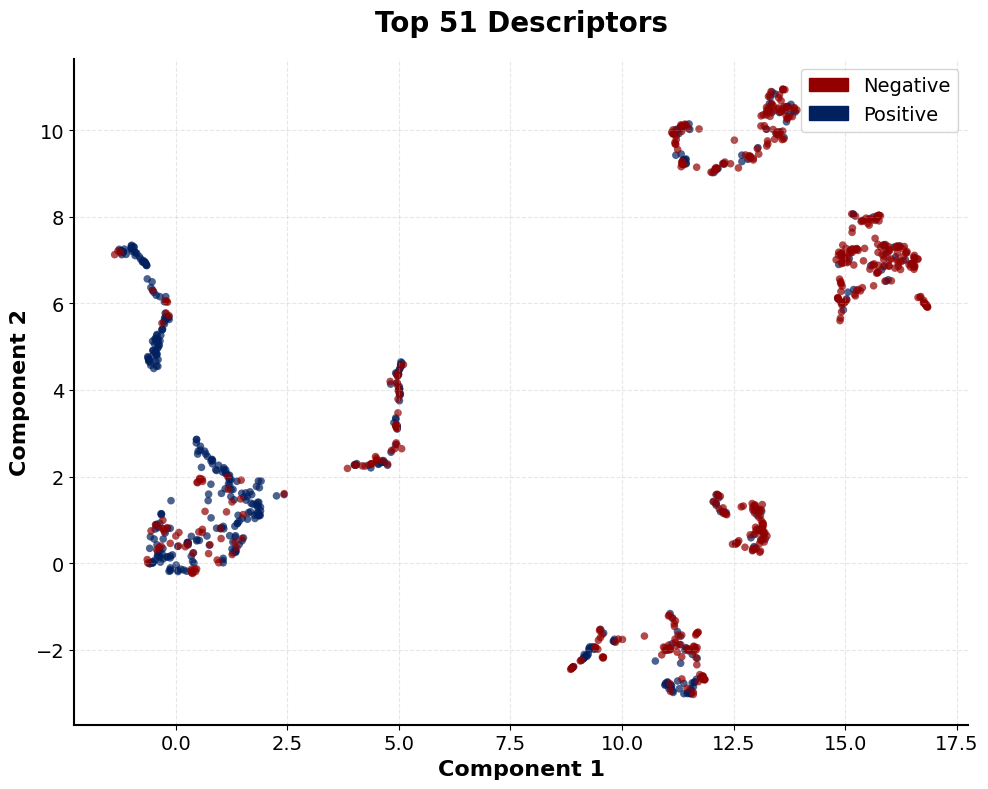

   ✓ Saved: ./model_results/UMAP_top79.jpg


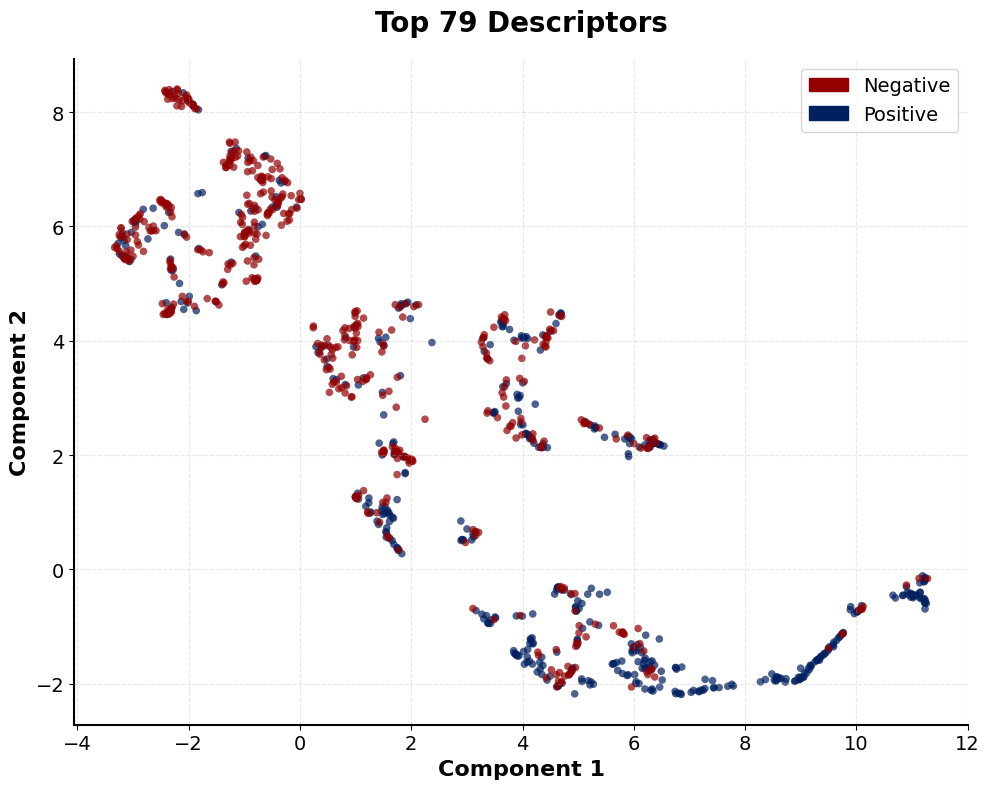

   ✓ Saved: ./model_results/UMAP_893.jpg


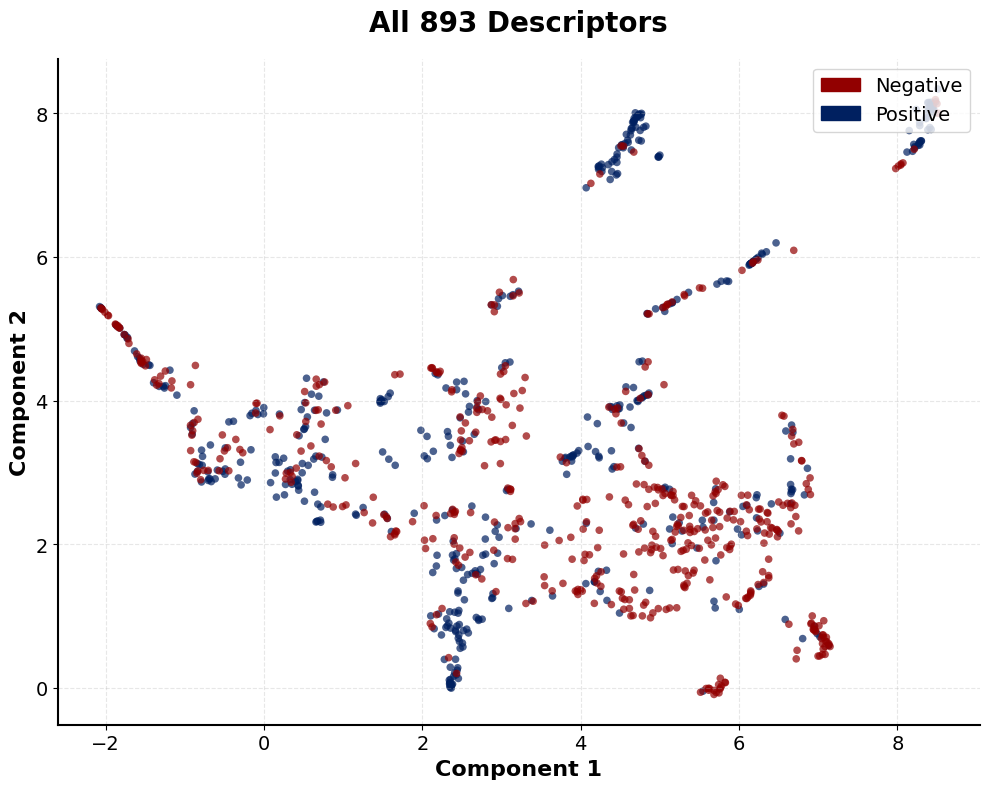


✅ UMAP visualizations saved to ./model_results/


In [91]:
### Plot UMAP Results ###
print("Generating UMAP visualizations...\n")

plot_dimreduction(
    umap_embedding_51, 
    'Top 51 Descriptors', 
    'UMAP_top51.jpg',
    colors_array,
    y_labels
)

plot_dimreduction(
    umap_embedding_79, 
    'Top 79 Descriptors', 
    'UMAP_top79.jpg',
    colors_array,
    y_labels
)

plot_dimreduction(
    umap_embedding_893, 
    'All 893 Descriptors', 
    'UMAP_893.jpg',
    colors_array,
    y_labels
)

print("\n✅ UMAP visualizations saved to ../Data/03_Model_training/02_Output/")

### **HCA**

In [ ]:
# ### Clustering function definition ###
# def plot_compound_clustermap(df, title="Compound ClusterMap", save_path=None, row_colors=None, col_colors=None):
#     """
#     Generate a compound-level hierarchical clustering heatmap.

#     Parameters:
#     - df: input data (n_samples x n_features) or similarity matrix
#     - row_colors: color bar on the left (per compound)
#     - col_colors: color bar on the top (per compound)
#     """
#     # Compute absolute correlation matrix (N x N)
#     compound_corr = df.T.corr().abs()

#     # Define custom color map (green scale)
#     cmap = sns.blend_palette(["#F8FBF6", "#001E00"], as_cmap=True)

#     # Generate hierarchical cluster map
#     g = sns.clustermap(
#         compound_corr,
#         cmap=cmap,
#         figsize=(22, 18),
#         annot=False,
#         row_colors=row_colors,
#         col_colors=col_colors,
#         dendrogram_ratio=(0.07, 0.1)
#     )

#     # Hide tick labels on heatmap
#     g.ax_heatmap.set_xticklabels([])
#     g.ax_heatmap.set_yticklabels([])
#     g.ax_heatmap.tick_params(bottom=False, right=False)
#     g.ax_heatmap.set_xlabel("1016 compounds", fontsize=24, fontweight='bold')

#     # Hide default colorbar and add custom one
#     g.cax.set_visible(False)
#     ax_colorbar = g.fig.add_axes([0.935, 0.05, 0.01, 0.75])
#     norm = plt.Normalize(vmin=0, vmax=1)
#     sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
#     sm.set_array([])
#     cbar = g.fig.colorbar(sm, cax=ax_colorbar)
#     cbar.ax.tick_params(labelsize=18)

#     # Add class legend (red = Negative, blue = Positive)
#     legend_patches = [
#         mpatches.Patch(color=light_red_hex, label='Negative'),
#         mpatches.Patch(color=light_blue_hex, label='Positive')
#     ]
#     g.fig.legend(
#         handles=legend_patches,
#         loc='upper left',
#         bbox_to_anchor=(0.001, 0.90),
#         ncol=1,
#         prop={'size': 18, 'weight': 'bold'}
#     )

#     # Set main title
#     g.fig.suptitle(title, fontsize=28, fontweight='bold', y=0.95)
#     g.fig.subplots_adjust(top=0.92, right=0.93, bottom=0.05)

#     # Save the figure
#     if save_path:
#         output_dir = "./model_results"
#         os.makedirs(output_dir, exist_ok=True)

#         # If only filename is given, add the default output_dir
#         if not os.path.isabs(save_path):
#             save_path = os.path.join(output_dir, save_path)

#         plt.savefig(save_path, dpi=300, bbox_inches="tight")
#         plt.show()

# ### Apllication of function ###
# plot_compound_clustermap(
#     elbow_1_51, 
#     title="Clustering with Top51 descriptors", 
#     save_path="compounds_clustermap_top51.jpg",
#     row_colors=row_colors,
#     col_colors=row_colors
# )

# plot_compound_clustermap(
#     elbow_2_79, 
#     title="Clustering with Top79 descriptors", 
#     save_path="compounds_clustermap_top79.jpg",
#     row_colors=row_colors,
#     col_colors=row_colors
# )

# plot_compound_clustermap(
#     df_scaled_x, 
#     title="Clustering with 893 descriptors", 
#     save_path="compounds_clustermap_893.jpg",
#     row_colors=row_colors,
#     col_colors=row_colors
# )


## **Step3: Model Construction and Validation**
This section describes the training, validation, and testing of five machine learning classifiers on two feature subsets (Top51 and Top79 descriptors) selected via feature importance analysis. 
The classifiers evaluated include Random Forest (RF), Support Vector Machine (SVM), XGBoost, Logistic Regression (LR), and Multi-layer Perceptron (MLP).

1. Load training and test sets with selected features.
2. Apply a 5-fold stratified cross-validation (CV) with hyperparameter optimization using `GridSearchCV`.
3. Evaluate each model using five metrics: Accuracy, AUC, F1-score, Matthews correlation coefficient (MCC), and Specificity.
4. Visualize ROC curves for both training and test sets.
5. Record the best hyperparameters and select the final model based on the test F1-score.

### **Evaluation Metrics**

The following metrics were computed for each model:
- **Accuracy**
- **Area Under the ROC Curve (AUC)**
- **F1-score**
- **Matthews Correlation Coefficient (MCC)**
- **Specificity**

### **Model Selection**

The best-performing model was selected based on the external test F1-score. For each classifier, we report:
- CV average and standard deviation
- Train and test performance
- Best hyperparameters

### **Comparative Test set performance**

Bar plots were used to summarize test performance across models and feature sets for the following metrics:
* F1-score
* MCC
* AUC
* Specificity

### **Outputs**
- `Data/03_Model_training/02_Output/performance_scores.csv`: Performance of all models across train/CV/test splits.
- `Data/03_Model_training/02_Output/best_hyperparameters.csv`: Optimal hyperparameter combinations for each model.
- `Data/03_Model_training/02_Output/ROC_curve_raw_<model>.jpg`: ROC curves for each model and feature set. (Fig. S2)

### **Figures**
- **Figure S2** ROC curves comparing training and test set AUC for the selected model.

#### **Load data with selected top descriptors and define model hyperparameters**

In [21]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, matthews_corrcoef, confusion_matrix, roc_curve, auc, make_scorer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from tqdm import tqdm

# Extract true class labels from training and test sets
Y_train_cls = train_cls["y_true"]
Y_test_cls = test_cls["y_true"]

# Define feature sets using the selected top descriptors
feature_sets = {
    "Top51": X_top_51.columns,
    "Top79": X_top_79.columns
}

# Define model pipelines and corresponding hyperparameter grids for GridSearchCV
models = [
    ('Random Forest', Pipeline([
        ('scaler', StandardScaler()),
        ('rf', RandomForestClassifier(random_state=1004, bootstrap=True))
    ]), {
        'rf__n_estimators': [100, 200],
        'rf__max_depth': [None, 10, 20],
        'rf__min_samples_leaf': [1, 2, 4],
        'rf__min_samples_split': [2, 5],
        'rf__max_features': ['sqrt']
    }),

    ('SVM', Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(probability=True, random_state=1004))
    ]), {
        'svm__kernel': ['linear', 'rbf'],
        'svm__C': [0.1, 1, 10],
        'svm__gamma': ['scale', 0.01]
    }),

    ('XGBoost', Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', XGBClassifier(eval_metric='logloss', random_state=1004))
    ]), {
        'xgb__n_estimators': [100, 200],
        'xgb__max_depth': [3, 5],
        'xgb__learning_rate': [0.01, 0.1],
        'xgb__subsample': [0.7, 0.8],
        'xgb__colsample_bytree': [0.8],
        'xgb__min_child_weight': [1, 3],
        'xgb__reg_lambda': [1, 3]
    }),

    ('Logistic Regression', Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(random_state=1004, max_iter=3000))
    ]), {
        'lr__C': [0.01, 0.1, 1, 10]
    }),

    ('MLP', Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(random_state=1004))
    ]), {
        'mlp__hidden_layer_sizes': [(50,), (100,), (100, 50), (128, 64, 32)],
        'mlp__activation': ['relu', 'tanh'],
        'mlp__solver': ['adam'], 
        'mlp__alpha': [0.0001, 0.001],
        'mlp__learning_rate': ['constant', 'adaptive'],
        'mlp__learning_rate_init': [0.001, 0.0005],
        'mlp__max_iter': [200, 300, 500],
        'mlp__early_stopping': [True]
    })
]

# Define stratified k-fold cross-validation to preserve class distribution
skfold = StratifiedKFold(n_splits=5, random_state=1004, shuffle=True)

# Dictionaries to store performance scores, best parameters, and best estimators
performance_scores = {}
best_params = {}
best_estimators_dict = {} 
test_roc_dict = {'Top51': [], 'Top79': []}

# Define custom scoring function for specificity
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

# Define evaluation metrics for GridSearchCV
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'mcc': make_scorer(matthews_corrcoef),
    'specificity': make_scorer(specificity_score)
}

#### **Function definition of model performance metrics with best hyperparameters**

In [19]:
def evaluate_model_no_smooth(grid_search_model, model_name, X_train_cls, Y_train_cls, X_test_cls, Y_test_cls, figure_path):
    
    best_model = grid_search_model.best_estimator_

    # Predict and evaluate performance on the training set
    y_train_pred = best_model.predict(X_train_cls)
    y_train_proba = best_model.predict_proba(X_train_cls)[:, 1]
    train_acc = accuracy_score(Y_train_cls, y_train_pred)
    train_auc = roc_auc_score(Y_train_cls, y_train_proba)
    train_f1 = f1_score(Y_train_cls, y_train_pred)
    train_mcc = matthews_corrcoef(Y_train_cls, y_train_pred)
    train_spec = specificity_score(Y_train_cls, y_train_pred)

    # Predict and evaluate performance on the test set
    y_test_pred = best_model.predict(X_test_cls)
    y_test_proba = best_model.predict_proba(X_test_cls)[:, 1]
    test_acc = accuracy_score(Y_test_cls, y_test_pred)
    test_auc = roc_auc_score(Y_test_cls, y_test_proba)
    test_f1 = f1_score(Y_test_cls, y_test_pred)
    test_mcc = matthews_corrcoef(Y_test_cls, y_test_pred)
    test_spec = specificity_score(Y_test_cls, y_test_pred)

    # Retrieve cross-validation results
    cv_results = grid_search_model.cv_results_
    best_idx = grid_search_model.best_index_
    cv_acc, cv_std_acc = cv_results['mean_test_accuracy'][best_idx], cv_results['std_test_accuracy'][best_idx]
    cv_auc, cv_std_auc = cv_results['mean_test_roc_auc'][best_idx], cv_results['std_test_roc_auc'][best_idx]
    cv_f1,  cv_std_f1  = cv_results['mean_test_f1'][best_idx], cv_results['std_test_f1'][best_idx]
    cv_mcc, cv_std_mcc = cv_results['mean_test_mcc'][best_idx], cv_results['std_test_mcc'][best_idx]
    cv_spec, cv_std_spec = cv_results['mean_test_specificity'][best_idx], cv_results['std_test_specificity'][best_idx]

    # Store performance metrics
    performance_scores[model_name] = {
        # Training set performance
        'Train Accuracy': train_acc, 'Train AUC': train_auc, 'Train F1': train_f1,
        'Train MCC': train_mcc, 'Train Specificity': train_spec,
        # Test set performance
        'Test Accuracy': test_acc, 'Test AUC': test_auc, 'Test F1': test_f1,
        'Test MCC': test_mcc, 'Test Specificity': test_spec,
        # Cross-validation performance (mean ± std)
        'CV Accuracy': cv_acc, 'CV Accuracy std': cv_std_acc,
        'CV AUC': cv_auc, 'CV AUC std': cv_std_auc,
        'CV F1': cv_f1, 'CV F1 std': cv_std_f1,
        'CV MCC': cv_mcc, 'CV MCC std': cv_std_mcc,
        'CV Specificity': cv_spec, 'CV Specificity std': cv_std_spec
    }
    
    # Store best hyperparameters and model
    best_params[model_name] = grid_search_model.best_params_
    best_estimators_dict[model_name] = best_model

    # === Plot original ROC curves for train and test ===
    fpr_train, tpr_train, _ = roc_curve(Y_train_cls, y_train_proba)
    fpr_test, tpr_test, _ = roc_curve(Y_test_cls, y_test_proba)

    plt.figure(figsize=(10, 10))
    plt.plot(fpr_train, tpr_train, color='tab:orange', lw=3.5,
             label=f'Train ROC (AUC={train_auc:.2f})', clip_on=False)
    plt.plot(fpr_test, tpr_test, color='tab:green', lw=3.5,
             label=f'Test ROC (AUC={test_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

    plt.xlabel('False Positive Rate', fontsize=21, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=21, fontweight='bold')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.yticks([tick for tick in plt.yticks()[0] if tick != 0])
    plt.tick_params(axis='both', which='both', direction='in', length=6, width=1.5, labelsize=18)
    plt.tick_params(top=True, right=True, bottom=True, left=True)

    # Adjust axis line thickness
    ax = plt.gca()
    for side in ['top', 'right', 'bottom', 'left']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.5)

    plt.title(f'{model_name}', fontsize=22, fontweight='bold', y=1.01)
    plt.legend(loc='lower right', fontsize=16)
    plt.grid(True, linestyle='--', linewidth='0.4')

    plt.tight_layout()

    # Save ROC curve plot to the specified directory
    os.makedirs(figure_path, exist_ok=True)
    roc_path = os.path.join(figure_path, f'ROC_curve_raw_{model_name}.jpg')
    plt.savefig(roc_path, dpi=300)
    plt.show()


# Define the path to save model evaluation results
figure_path = '../Data/03_Model_training/02_Output'

#### **Application of function through each subset**

Feature Sets:   0%|                                                                                               | 0/2 [00:00<?, ?it/s]


=== Feature Set: Top51 ===



els for Top51:   0%|                                                                                           | 0/5 [00:00<?, ?it/s]


[Model: Random Forest | Features: Top51] GridSearch Started
Fitting 5 folds for each of 36 candidates, totalling 180 fits


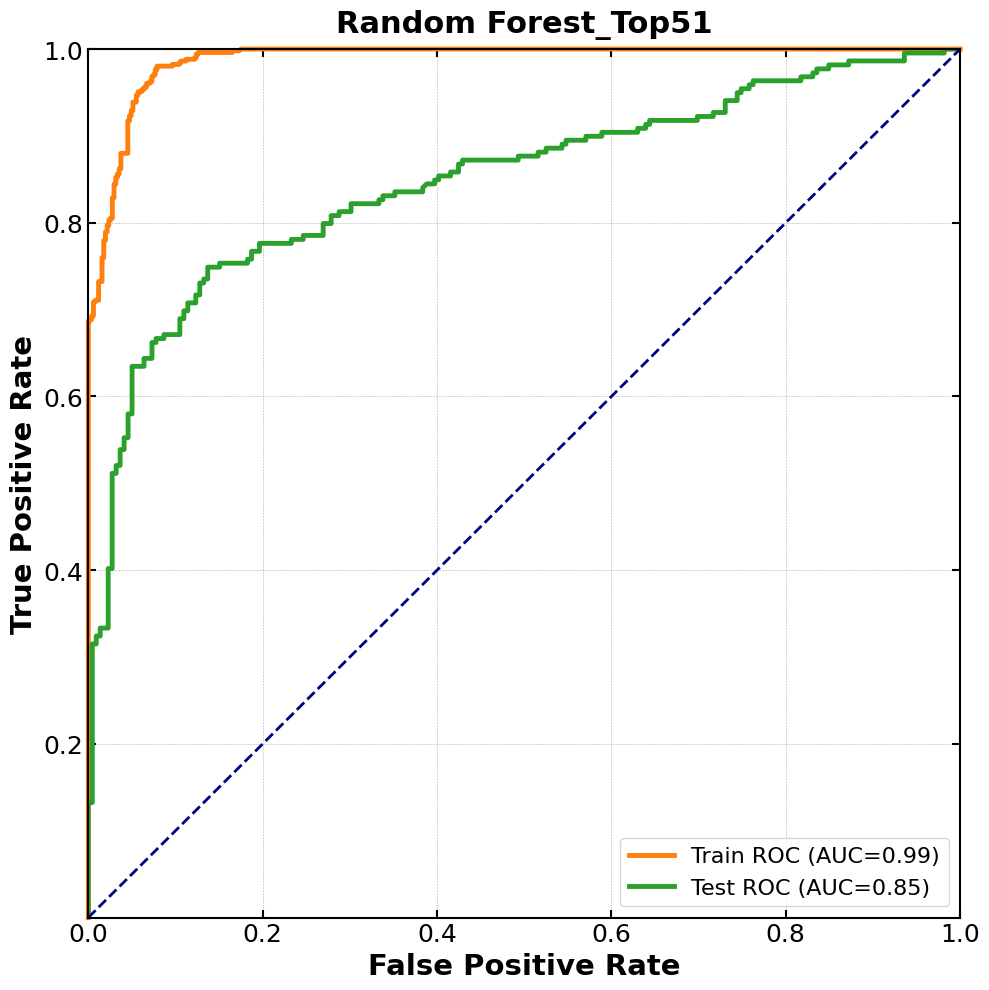


els for Top51:  20%|████████████████▌                                                                  | 1/5 [00:08<00:34,  8.59s/it]


[Model: SVM | Features: Top51] GridSearch Started
Fitting 5 folds for each of 12 candidates, totalling 60 fits


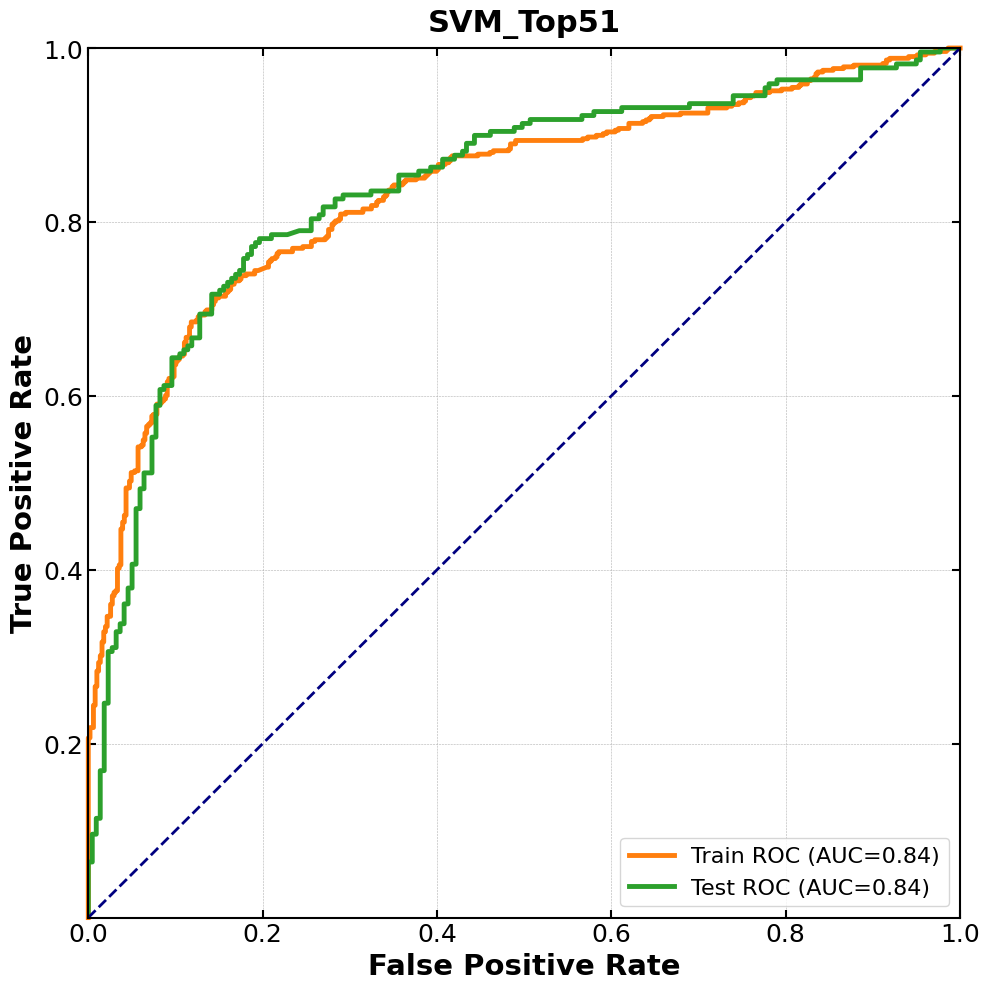


els for Top51:  40%|█████████████████████████████████▏                                                 | 2/5 [00:12<00:16,  5.62s/it]


[Model: XGBoost | Features: Top51] GridSearch Started
Fitting 5 folds for each of 64 candidates, totalling 320 fits


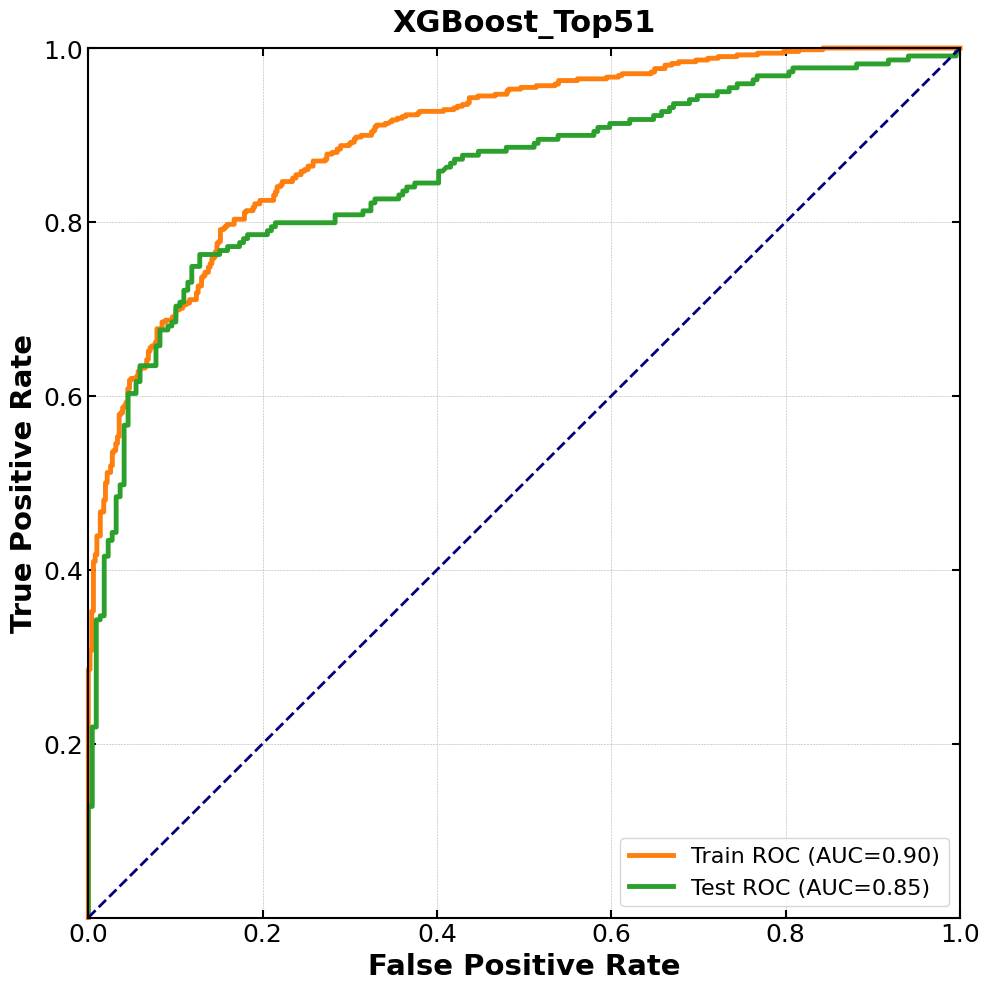


els for Top51:  60%|█████████████████████████████████████████████████▊                                 | 3/5 [00:22<00:15,  7.60s/it]


[Model: Logistic Regression | Features: Top51] GridSearch Started
Fitting 5 folds for each of 4 candidates, totalling 20 fits


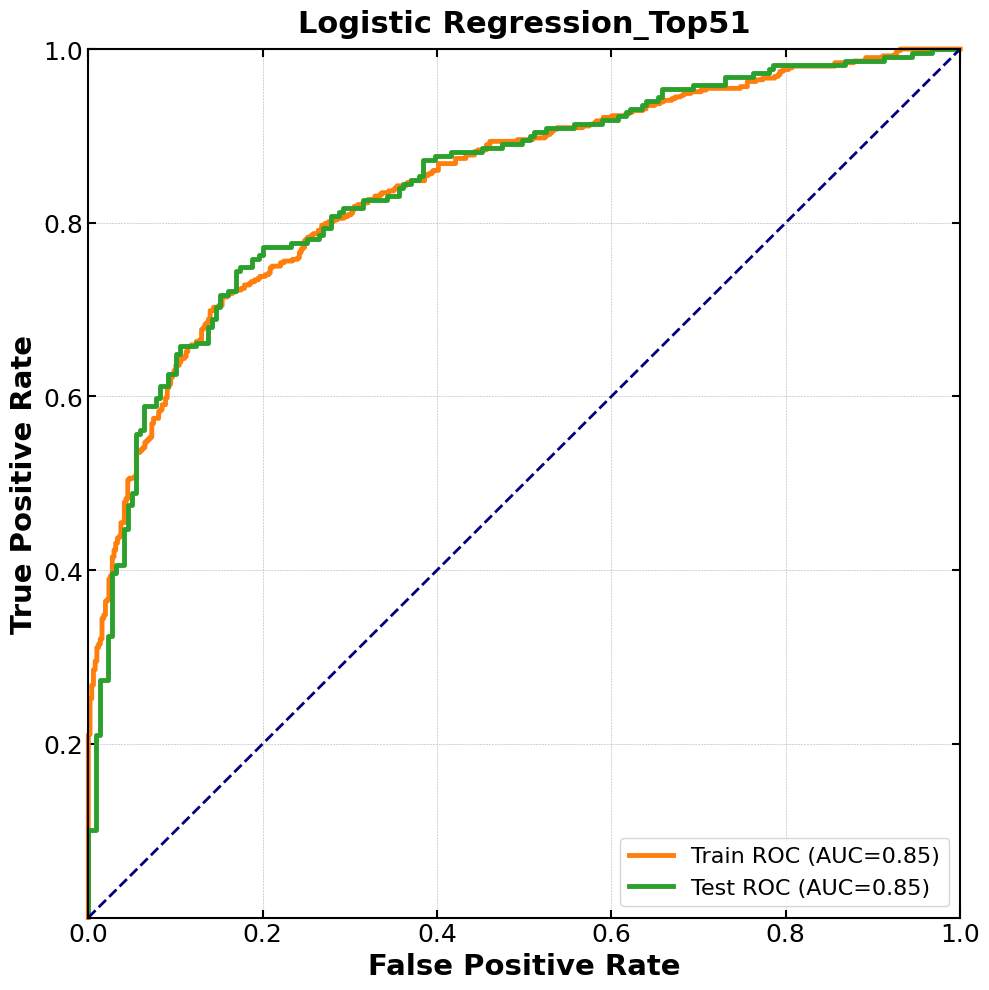


els for Top51:  80%|██████████████████████████████████████████████████████████████████▍                | 4/5 [00:22<00:04,  4.81s/it]


[Model: MLP | Features: Top51] GridSearch Started
Fitting 5 folds for each of 192 candidates, totalling 960 fits


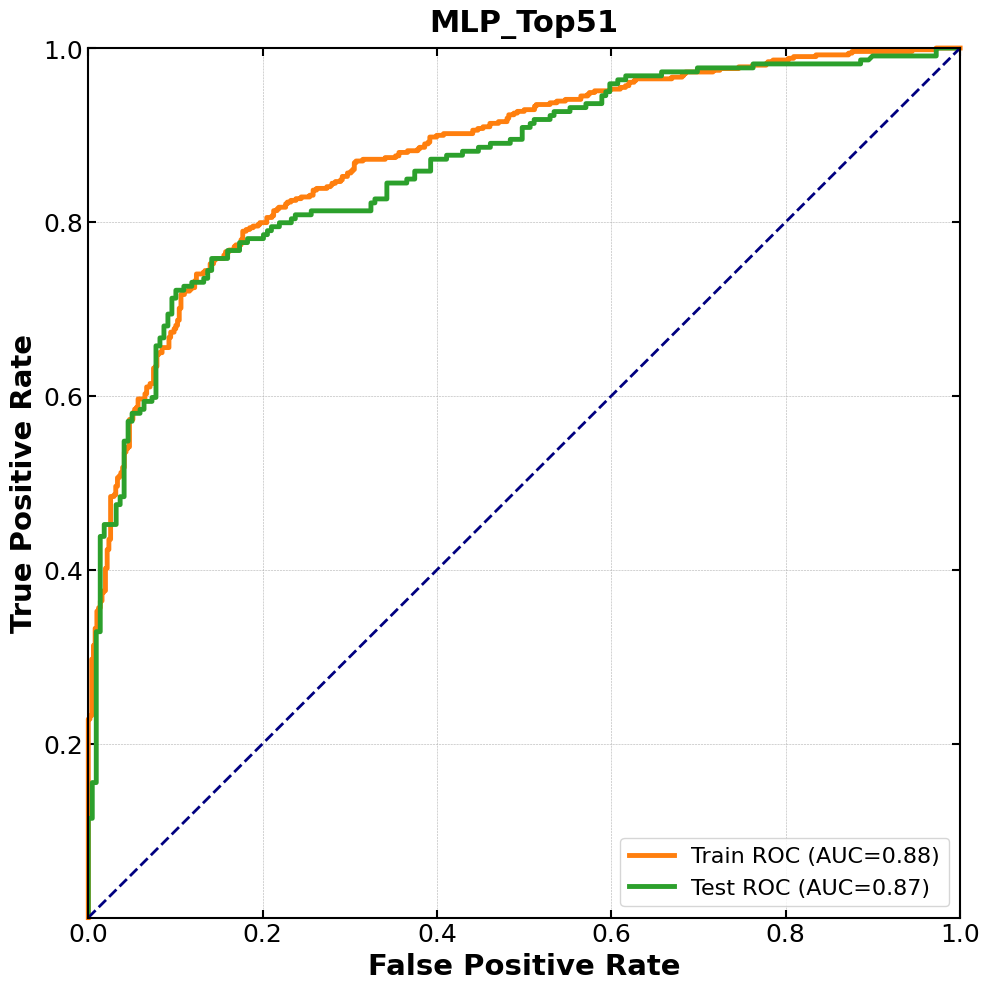


Feature Sets:  50%|███████████████████████████████████████████▌                                           | 1/2 [00:32<00:32, 32.83s/it]


=== Performance Summary for Feature Set: Top51 ===

=== Random Forest_Top51 ===
F1 Score:       Train=0.9337, CV=0.7453, Test=0.7850
AUC:            Train=0.9879, CV=0.8220, Test=0.8479
Accuracy:       Train=0.9350, CV=0.7589, Test=0.7900
MCC:            Train=0.8708, CV=0.5222, Test=0.5805
Specificity:    Train=0.9547, CV=0.8111, Test=0.8128
Best Params:    {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}

=== SVM_Top51 ===
F1 Score:       Train=0.7689, CV=0.7509, Test=0.7889
AUC:            Train=0.8376, CV=0.8116, Test=0.8394
Accuracy:       Train=0.7776, CV=0.7618, Test=0.7922
MCC:            Train=0.5567, CV=0.5269, Test=0.5848
Specificity:    Train=0.8150, CV=0.8031, Test=0.8082
Best Params:    {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}

=== XGBoost_Top51 ===
F1 Score:       Train=0.7954, CV=0.7440, Test=0.8000
AUC:            Train=0.8986, CV=0.8227, Test=0.8537
Accuracy:      


els for Top79:   0%|                                                                                           | 0/5 [00:00<?, ?it/s]


[Model: Random Forest | Features: Top79] GridSearch Started
Fitting 5 folds for each of 36 candidates, totalling 180 fits


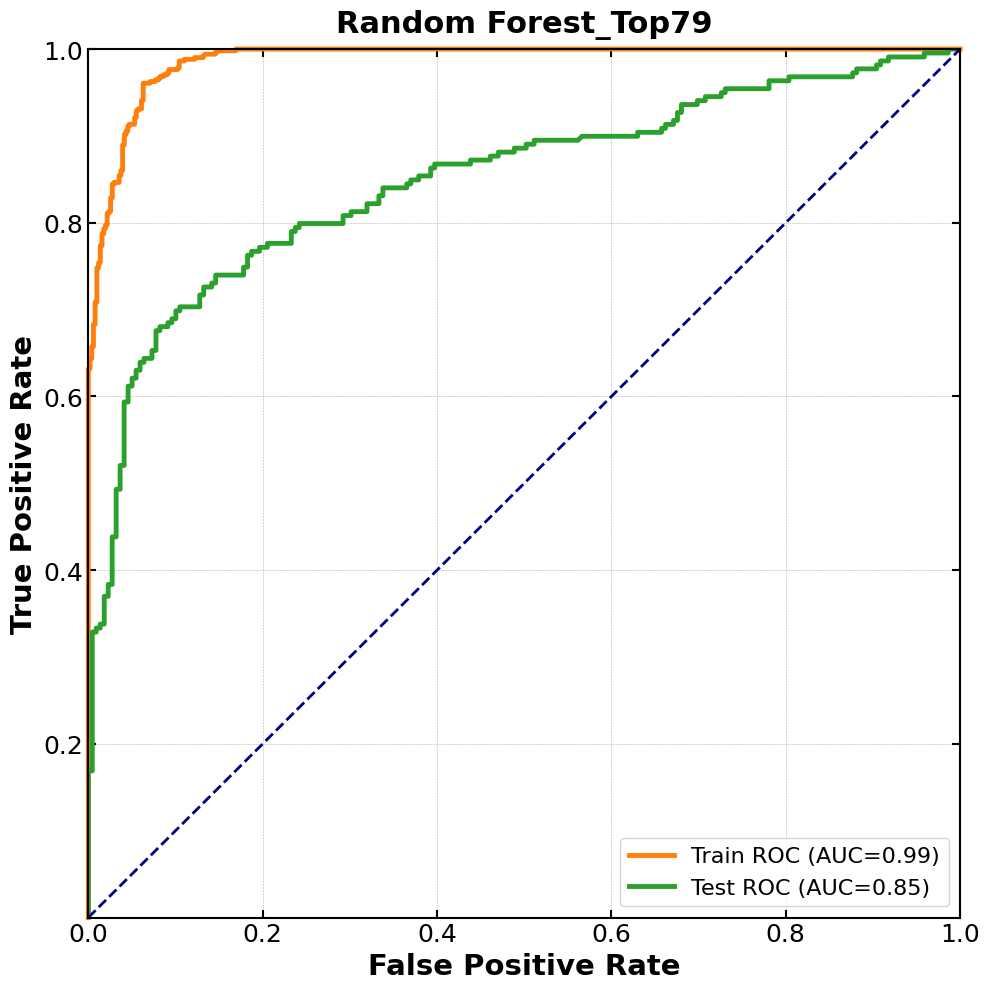


els for Top79:  20%|████████████████▌                                                                  | 1/5 [00:08<00:33,  8.32s/it]


[Model: SVM | Features: Top79] GridSearch Started
Fitting 5 folds for each of 12 candidates, totalling 60 fits


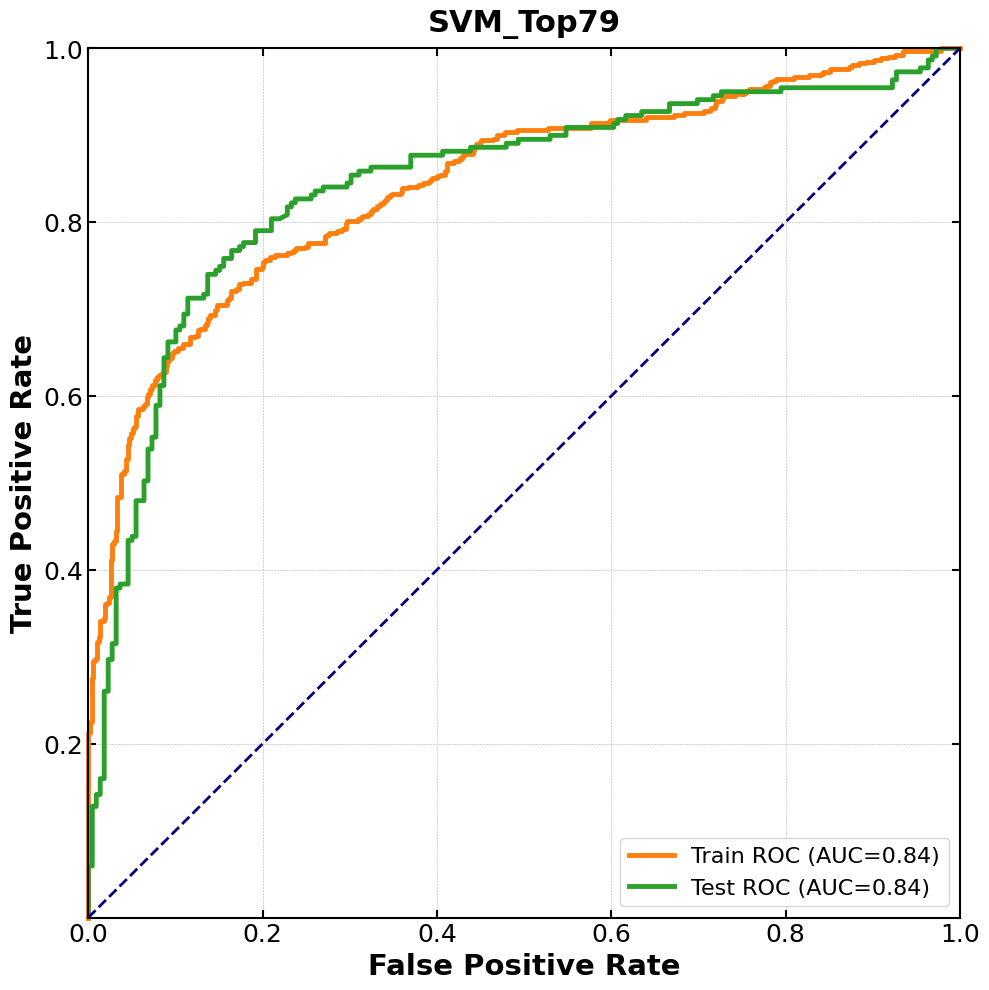


els for Top79:  40%|█████████████████████████████████▏                                                 | 2/5 [00:14<00:21,  7.18s/it]


[Model: XGBoost | Features: Top79] GridSearch Started
Fitting 5 folds for each of 64 candidates, totalling 320 fits


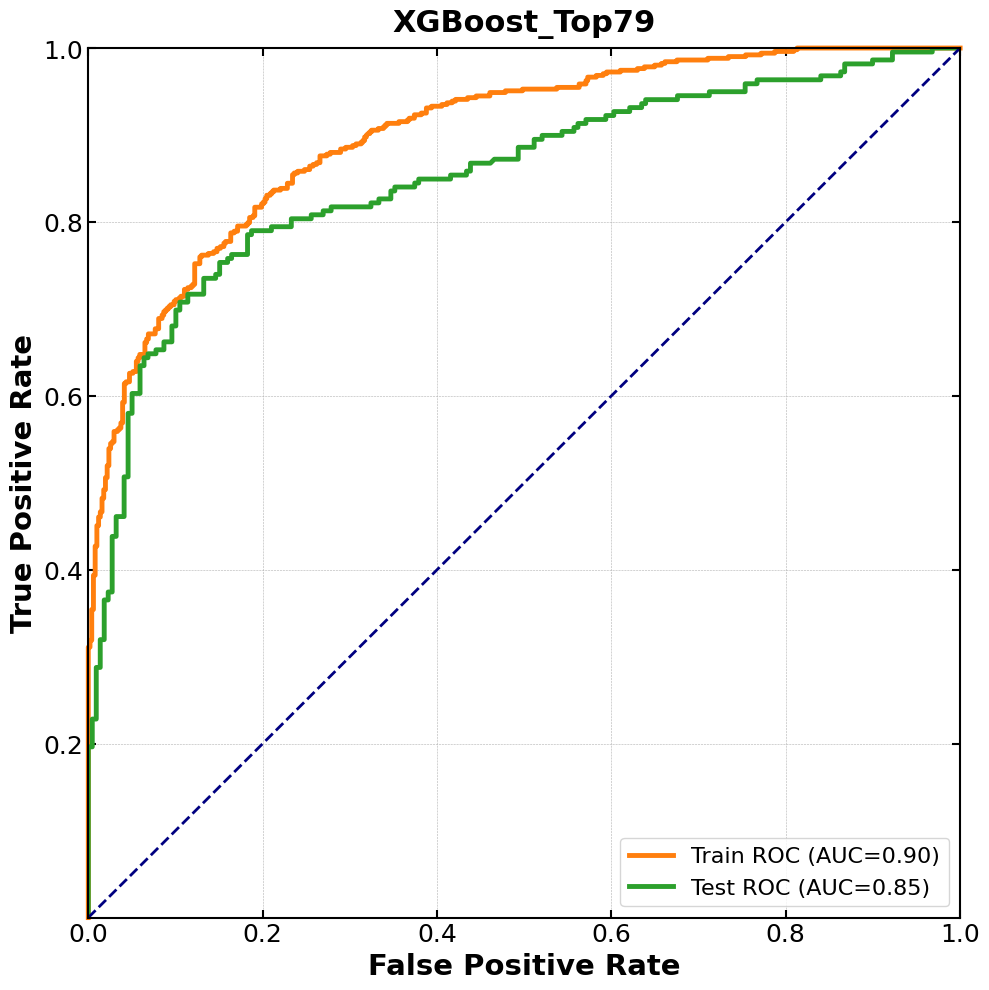


els for Top79:  60%|█████████████████████████████████████████████████▊                                 | 3/5 [00:30<00:22, 11.23s/it]


[Model: Logistic Regression | Features: Top79] GridSearch Started
Fitting 5 folds for each of 4 candidates, totalling 20 fits


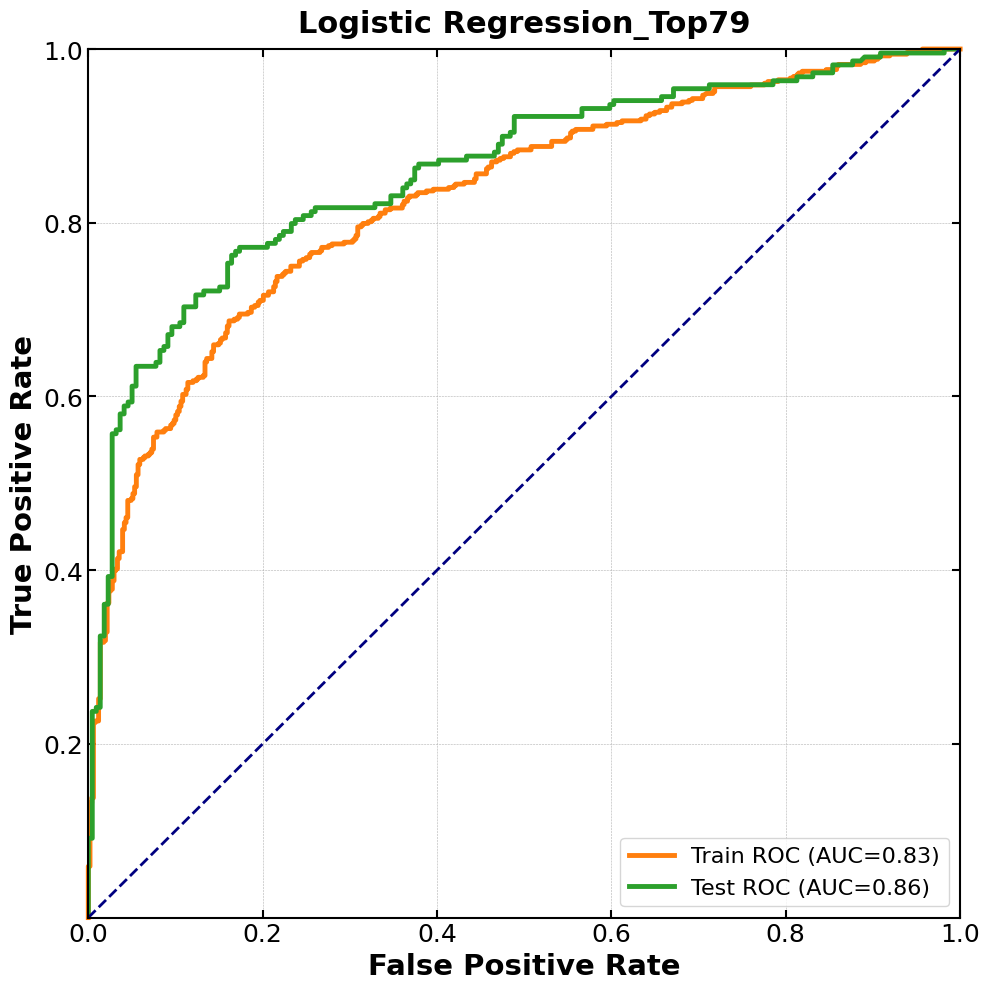


els for Top79:  80%|██████████████████████████████████████████████████████████████████▍                | 4/5 [00:31<00:06,  6.97s/it]


[Model: MLP | Features: Top79] GridSearch Started
Fitting 5 folds for each of 192 candidates, totalling 960 fits


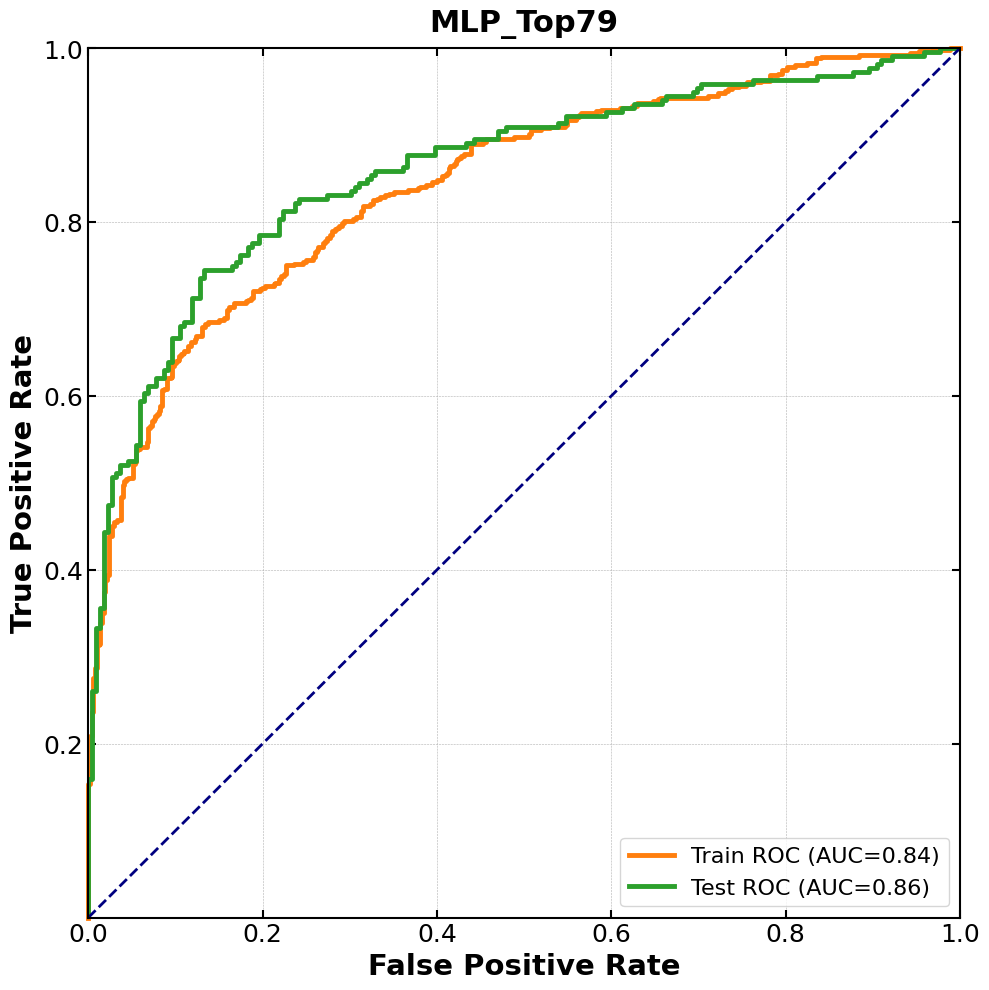


Feature Sets: 100%|███████████████████████████████████████████████████████████████████████████████████████| 2/2 [01:13<00:00, 36.73s/it]


=== Performance Summary for Feature Set: Top79 ===

=== Random Forest_Top79 ===
F1 Score:       Train=0.9271, CV=0.7452, Test=0.7714
AUC:            Train=0.9875, CV=0.8245, Test=0.8493
Accuracy:       Train=0.9291, CV=0.7608, Test=0.7808
MCC:            Train=0.8596, CV=0.5272, Test=0.5636
Specificity:    Train=0.9567, CV=0.8229, Test=0.8219
Best Params:    {'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}

=== SVM_Top79 ===
F1 Score:       Train=0.7633, CV=0.7436, Test=0.7900
AUC:            Train=0.8433, CV=0.8057, Test=0.8438
Accuracy:       Train=0.7717, CV=0.7529, Test=0.7900
MCC:            Train=0.5447, CV=0.5090, Test=0.5799
Specificity:    Train=0.8071, CV=0.7893, Test=0.7900
Best Params:    {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}

=== XGBoost_Top79 ===
F1 Score:       Train=0.8013, CV=0.7463, Test=0.7873
AUC:            Train=0.9003, CV=0.8247, Test=0.8523
Accuracy:      

In [22]:
# Iterate through each feature subset (Top51, Top79)
for feature_name, col_list in tqdm(feature_sets.items(), desc="Feature Sets", total=len(feature_sets)):
    print(f"\n=== Feature Set: {feature_name} ===")
    
    # Extract selected features for training and testing
    X_train_df = train_cls[col_list]
    X_test_df = test_cls[col_list]

    # Loop over each model and perform GridSearchCV
    for model_name, pipeline, param_grid in tqdm(models, desc=f"Models for {feature_name}", total=len(models)):
        print(f"\n[Model: {model_name} | Features: {feature_name}] GridSearch Started")

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=skfold,
            scoring=scoring,
            refit='f1',
            n_jobs=16,
            verbose=1
        )

        # Fit on training data
        grid_search.fit(X_train_df, Y_train_cls)

        # Save best estimator
        best_estimators_dict[f'{model_name}_{feature_name}'] = grid_search.best_estimator_

        # Evaluate on train and test sets, plot ROC
        evaluate_model_no_smooth(
            grid_search,
            f'{model_name}_{feature_name}',
            X_train_df, Y_train_cls,
            X_test_df, Y_test_cls,
            figure_path
        )

    # Print performance summary for this feature subset
    print(f"\n=== Performance Summary for Feature Set: {feature_name} ===")
    for model_key, scores in performance_scores.items():
        if feature_name in model_key:
            print(f"\n=== {model_key} ===")
            print(f"F1 Score:       Train={scores['Train F1']:.4f}, CV={scores['CV F1']:.4f}, Test={scores['Test F1']:.4f}")
            print(f"AUC:            Train={scores['Train AUC']:.4f}, CV={scores['CV AUC']:.4f}, Test={scores['Test AUC']:.4f}")
            print(f"Accuracy:       Train={scores['Train Accuracy']:.4f}, CV={scores['CV Accuracy']:.4f}, Test={scores['Test Accuracy']:.4f}")
            print(f"MCC:            Train={scores['Train MCC']:.4f}, CV={scores['CV MCC']:.4f}, Test={scores['Test MCC']:.4f}")
            print(f"Specificity:    Train={scores['Train Specificity']:.4f}, CV={scores['CV Specificity']:.4f}, Test={scores['Test Specificity']:.4f}")
            print(f"Best Params:    {best_params[model_key]}")

# Select the final model based on highest Test F1 score
best_model_name = None
best_test_f1 = 0.0
for model_key, scores in performance_scores.items():
    if scores['Test F1'] > best_test_f1:
        best_test_f1 = scores['Test F1']
        best_model_name = model_key

print(f"\nFinal selected model: {best_model_name} (Test F1 = {best_test_f1:.4f})")

# Display all best estimators
for name, est in best_estimators_dict.items():
    print(f"Best Estimator: {name} -> {est}")

# Save performance results to CSV
performance_df = pd.DataFrame.from_dict(performance_scores, orient='index')
performance_df = performance_df.round(4)
performance_df.to_csv("../Data/03_Model_training/02_Output/performance_scores.csv", index=True)

# Save best hyperparameters to CSV
params_df = pd.DataFrame.from_dict(best_params, orient='index')
params_df.to_csv("../Data/03_Model_training/02_Output/best_hyperparameters.csv", index=True)


### **Save the final model to .pkl**

In [ ]:
import joblib

joblib.dump(best_estimators_dict["XGBoost_Top51"], "../Model/XGBoost_Top51_model.pkl")

## **Step4: External Validation using ZINC Natural Products Data**
We evaluated the generalizability of the final model using an external compound library derived from the ZINC Natural Products ADMET dataset (n=9,644).
    * ✅ Input data: `Data/01_Raw/ZINC_Natural_Products_ADMET_9644.smi`
1. Data Preprocessing
    * Stereochemistry Removal: @ symbols were removed from SMILES to standardize molecular representation.
    * Duplicate Filtering: Only one compound was retained per unique backbone (simplified SMILES).
    * NaN Removal: Compounds with missing SMILES were excluded.
    * ✅ Resulting dataset: `Data/02_Preprocessed/01_Remove_duplication_NaN/ZINC_Natural_Products_ADMET_5810.smi`
2. Metal Ion Filtering
    * ✅ Resulting dataset: `Data/02_Preprocessed/02_Filtered_metal_ions/ZINC_Natural_Products_ADMET_filtered.smi`
3. Descriptor Calculation (PaDEL)
    * ✅ `Data/03_Model_training/02_Output/ZINC_external_des_5810.csv`
4. Prediction using Final Model
    * Preprocess the descriptor data
        * ✅ `Data/03_Model_training/02_Output/ZINC_external_5790.csv`
    * Model Used: XGBoost_Top51 (selected based on best test F1-score from Step 2)
    * Prediction Outputs:
        * Predicted_Probability: class 1 (positive) prediction probability
        * Predicted_Class: binary output (0/1)
    * Top 5% most probable antioxidant-like compounds were extracted:
        * ✅ `Data/03_Model_training/02_Output/ZINC_external_5%_predictions_XGB51.csv` (n ≈ 289)



#### **Preprocessing ZINC SMILES**

In [29]:
import pandas as pd
import pandas as pd
import requests
import time
from typing import Dict, Optional
import json
from tqdm import tqdm

# Load original SMILES file
input_file = '../Data/01_Raw/ZINC_Natural_Products_ADMET_9644.smi'
df = pd.read_csv(input_file, sep='\s+', names=['SMILES', 'Name'], engine='python')

# Remove stereochemical information (e.g., '@')
df['simplified_SMILES'] = df['SMILES'].str.replace('@', '')

# Remove duplicates based on simplified SMILES
df_dup = df.drop_duplicates(subset='simplified_SMILES', keep='first', ignore_index=True)
df_dup = df_dup.drop(columns=['SMILES'])
df_dup = df_dup[['simplified_SMILES', 'Name']]
df_dup = df_dup.rename(columns={'simplified_SMILES': 'SMILES'})                                                              # n = 5810

# Drop rows with missing SMILES
df_nan = df_dup.dropna(subset=['SMILES'], ignore_index=True)

# Save the cleaned file
df_nan.to_csv('../Data/02_Preprocessed/01_Remove_duplication_NaN/ZINC_Natural_Products_ADMET_5810.smi', sep='\t', index=False, header=False)

#### **Remove Metal-Containing Compounds**

In [31]:
def filter_metal_ions(smiles_file, output_file):
    metal_ions = ['Li', 'Be', 'Na', 'Mg', 'Al', 'K', 'Ca', 'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn',
                  'Ga', 'Ge', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Mo', 'Tc', 'Ru', 'Rh', 'Pd', 'Ag', 'Cd', 'In', 'Sn',
                  'Sb', 'Cs', 'Ba', 'La', 'Ce', 'Pr', 'Nd', 'Pm', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm',
                  'Yb', 'Lu', 'Hf', 'Ta', 'W', 'Re', 'Os', 'Ir', 'Pt', 'Au', 'Hg', 'Tl', 'Pb', 'Bi', 'Th', 'Pa', 'U','[R]',';v']
    
    with open(smiles_file, 'r') as infile, open(output_file, 'w') as outfile:
        for line in infile:
            smile, name = line.strip().split('\t')
            if not any(metal in smile for metal in metal_ions):
                outfile.write(f"{smile}\t{name}\n")

filter_metal_ions('../Data/02_Preprocessed/01_Remove_duplication_NaN/ZINC_Natural_Products_ADMET_5810.smi', '../Data/02_Preprocessed/02_Filtered_metal_ions/ZINC_Natural_Products_ADMET_filtered.smi')

#### **Descriptor Calculation with PaDEL**

In [32]:
from padelpy import padeldescriptor

padeldescriptor(mol_dir='../Data/02_Preprocessed/02_Filtered_metal_ions/ZINC_Natural_Products_ADMET_filtered.smi', d_file='../Data/03_Model_training/02_Output/ZINC_external_des_5810.csv', 
                d_2d=True, d_3d=False, detectaromaticity=True, 
                log=True, removesalt=True, standardizenitro=True, 
                usefilenameasmolname=False, 
                retainorder=True, threads=-1, waitingjobs=-1, 
                maxruntime=10000, maxcpdperfile=0, headless=True)

#### **Predict Using Final Model**

In [100]:
import joblib
import pandas as pd

# Load saved model
final_model = joblib.load("../Model/XGBoost_Top51_model.pkl")

# External dataset (already preprocessed)
external = pd.read_csv('../Data/03_Model_training/02_Output/ZINC_external_des_5810.csv', index_col='Name')                                  # n = 5810
external = external.drop_duplicates().dropna()                                                          # n = 5790
external.to_csv('../Data/03_Model_training/02_Output/ZINC_external_5790.csv', index=False)

# Load selected descriptor names (FIXED: correct filename)
with open("../Data/02_Preprocessed/03_Feature_selection/top_51_features.txt", "r") as f:
    top_51_features = [line.strip() for line in f]

# Apply to external dataset
X_external = external[top_51_features]

# Predict probabilities and classes
external["Predicted_Probability"] = final_model.predict_proba(X_external)[:, 1]
external["Predicted_Class"] = final_model.predict(X_external)

# Sort by predicted probability
external_df = external[["Predicted_Probability", "Predicted_Class"]]
external_df = external_df.sort_values(by="Predicted_Probability", ascending=False)

# Save results
external_df.to_csv("../Data/03_Model_training/02_Output/ZINC_external_predictions_XGB51.csv")

In [101]:
print(external_df["Predicted_Class"].value_counts())

Predicted_Class
0    3626
1    2164
Name: count, dtype: int64


#### **Extract Top 5% Hits**

In [105]:
# Get top 5% based on predicted probability
top_n = int(len(external_df) * 0.05)
top_5_percent_df = external_df.head(top_n)

# Save and summarize
top_5_percent_df.to_csv("../Data/03_Model_training/02_Output/ZINC_external_5%_predictions_XGB51.csv")
print(f"🔝 Top 5% threshold: {external_df['Predicted_Probability'].iloc[top_n - 1]:.4f}")
print(f"🎯 Top 5% compounds: {len(top_5_percent_df)} / {len(external_df)}")

🔝 Top 5% threshold: 0.8034
🎯 Top 5% compounds: 289 / 5790


In [102]:
external_df.head(50)

,Predicted_Probability,Predicted_Class
Name,,
ZINC95099548,0.893044,1
ZINC85596409,0.892095,1
ZINC13481878,0.888080,1
ZINC13461250,0.887963,1
ZINC29125697,0.887520,1
ZINC29042018,0.886577,1
ZINC14435949,0.882353,1
ZINC05999049,0.880204,1
ZINC32501378,0.878755,1


/bin/bash: sklearn: command not found
